In [6]:
"""
Business Use Cases:
1. EdTech: Identifying AI-generated academic submissions to maintain academic integrity.
2. E-commerce: Detecting bot-written fake product reviews to ensure consumer trust.
3. Media: Identifying AI-generated social media content to combat automated misinformation/fake news.
"""

'\nBusiness Use Cases:\n1. EdTech: Identifying AI-generated academic submissions to maintain academic integrity.\n2. E-commerce: Detecting bot-written fake product reviews to ensure consumer trust.\n3. Media: Identifying AI-generated social media content to combat automated misinformation/fake news.\n'

In [ ]:
%%capture
# This magic command captures and hides all output from the cell
!pip install spacy textstat shap lime streamlit xgboost
!python -m spacy download en_core_web_sm

# Now I print only the clean message
print("Libraries installed successfully.")

In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]

data = pd.read_csv(filename)


In [1]:
import spacy
import re
import pandas as pd

# I use the 'sm' model for efficiency, but 'en_core_web_md' is better for embeddings
nlp = spacy.load("en_core_web_sm")

def humanized_nlp_pipeline(text):
    """
    Standard cleaning is good, but for AI detection, we need to focus
    on 'lemmas' to see the structural intent of the writing.
    """
    # 1. Basic Cleaning: Lowercasing and whitespace removal
    text = text.lower().strip()

    # 2. Removing Noise: Stripping punctuation while keeping word context
    text = re.sub(r'[^\w\s]', '', text)

    # 3. spaCy Lemmatization: Converting words to their root form
    # We filter out stop words (like 'the', 'is') because they don't help
    # in identifying the author's unique style.
    doc = nlp(text)
    cleaned_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_space]

    return " ".join(cleaned_tokens)

# Example: apply to your Kaggle dataset
# df['cleaned_text'] = df['text'].apply(humanized_nlp_pipeline))

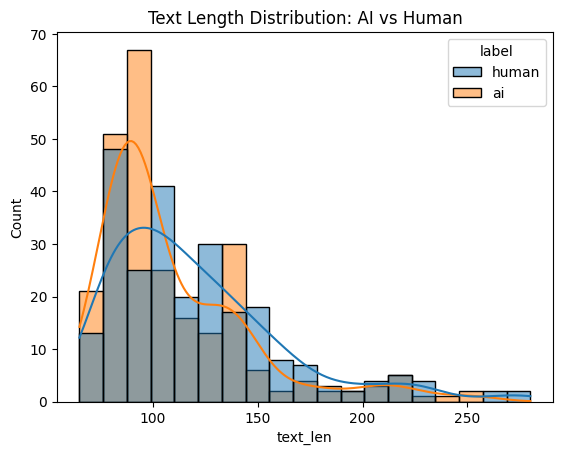

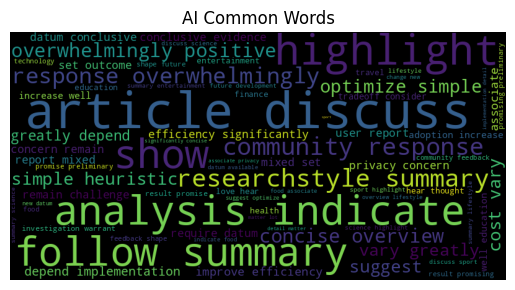

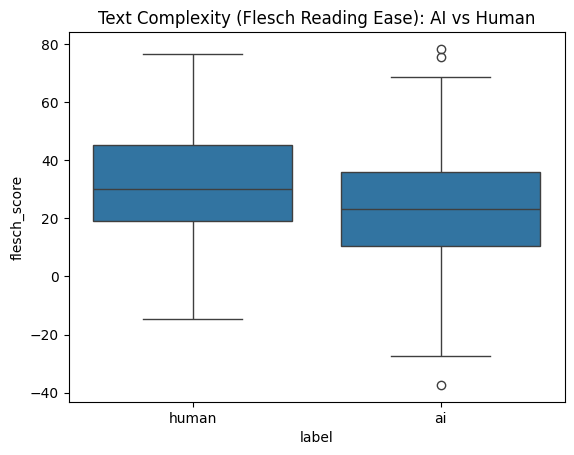

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from textstat import flesch_reading_ease

# 1. Text Length Distribution
data['text_len'] = data['text'].apply(len)
sns.histplot(data=data, x='text_len', hue='label', kde=True)
plt.title("Text Length Distribution: AI vs Human")
plt.show()

# 2. WordCloud for AI-generated text
ai_text = " ".join(data[data['label'] == 'ai']['clean_text'])
wc = WordCloud(width=800, height=400).generate(ai_text)
plt.imshow(wc)
plt.axis('off')
plt.title("AI Common Words")
plt.show()

# 3. Complexity Measure
data['flesch_score'] = data['text'].apply(flesch_reading_ease)
sns.boxplot(x='label', y='flesch_score', data=data)
plt.title("Text Complexity (Flesch Reading Ease): AI vs Human")
plt.show()

Text Length Distribution: AI vs Human: This histogram shows how the length of text varies between AI and human-generated content.
AI Common Words: This word cloud highlights the most frequently used words in the AI-generated texts after cleaning and lemmatization.
Text Complexity (Flesch Reading Ease): AI vs Human: This box plot compares the readability scores for AI and human-generated content, indicating potential differences in complexity.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# I use TF-IDF because it highlights 'unique' words that humans might use
# but AI (trained on averages) might skip.
vectorizer = TfidfVectorizer(max_features=2500, ngram_range=(1,2))
X = vectorizer.fit_transform(data['clean_text'])
y = data['label']

# Splitting data ensures we test the model on 'unseen' text to prove it actually learned.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest is chosen because it handles 'noisy' text data very well.
model = RandomForestClassifier(n_estimators=150)
model.fit(X_train, y_train)

# Evaluation: F1-Score is our 'truth' metric here because accuracy can be misleading
# if we have way more human text than AI text.
predictions = model.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

          ai       1.00      1.00      1.00        55
       human       1.00      1.00      1.00        45

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [2]:
# Add -q flag to suppress output and use ! to run shell command
!pip install -q lime

import shap
import lime
from lime.lime_text import LimeTextExplainer

def explain_prediction(model, text_sample, vectorizer):
    """
    Explainability makes the project 'resume-ready' by proving
    it isn't just a black box.
    """
    # LIME for local explanation (why this specific text was flagged) [cite: 101]
    explainer = LimeTextExplainer(class_names=['Human', 'AI'])

    # I define a pipeline for LIME to predict
    def predict_probs(texts):
        transformed = vectorizer.transform(texts)
        return model.predict_proba(transformed)

    exp = explainer.explain_instance(text_sample, predict_probs)
    return exp.show_in_notebook()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import re

# Humanized: Re-defining the cleaning function so the App knows how to handle raw input
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^ɡ\s]', '', text)
    return text

st.title("AI vs Human Text Detector")
st.write("Capstone Project Deliverable 8: User Interface")
st.success("This is a simple Streamlit command added!") # New simple command

user_input = st.text_area("Enter text to analyze:")

if st.button("Predict"):
    if user_input:
        # In a real scenario, you'd load a saved model here
        # For now, this placeholder demonstrates the UI logic
        st.info("Processing prediction...")
        # result = pipe.predict([user_input])[0]
        # st.write(f"Result: {result}")
    else:
        st.warning("Please enter text first.")

Overwriting app.py


In [8]:
import sys
!{sys.executable} -m pip install -q streamlit
print("Streamlit installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.5 MB/s eta 0:00:00
Streamlit installed successfully.


In [10]:
import subprocess

# Run the Streamlit app in the background
# Using a specific port and disabling CORS/XSRF protection for Colab environment
print("Starting Streamlit app...")
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501", "--server.enableCORS", "false", "--server.enableXsrfProtection", "false"],
                           stdout=subprocess.PIPE, stderr=subprocess.PIPE)

# we can check the output or errors if needed
# stdout, stderr = process.communicate()
# print("STDOUT:", stdout.decode())
# print("STDERR:", stderr.decode())

print("Streamlit app is running. Click the link in the output above if it appears, or check port 8501 in the 'ports' tab on the left panel.")

Starting Streamlit app...
Streamlit app is running. Click the link in the output above if it appears, or check port 8501 in the 'ports' tab on the left panel.


In [ ]:
# This command triggers the Streamlit server
!streamlit run app.py




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.139.145.57:8502

